# U-Net Architecture

In [1]:
# Importing libraries

import torch
import torch.nn as nn
import torch.nn.functional as F


In [3]:
# U-Net building blocks

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


In [4]:
# Encoder + Decoder

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.dec4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final(d1)


## Trainning Section

In [ ]:
import os
import cv2
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm



In [10]:
# Custom Dataset Class

class CTStrokeDataset(Dataset):
    def __init__(self, image_dir, label_dir):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.images = sorted(os.listdir(image_dir))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]

        img_path = os.path.join(self.image_dir, img_name)
        lbl_path = os.path.join(self.label_dir, img_name)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        label = cv2.imread(lbl_path, cv2.IMREAD_GRAYSCALE)

        image = image / 255.0
        label = label / 255.0

        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.float32).unsqueeze(0)

        return image, label


In [16]:
# Dataset & DataLoader

train_image_dir = r"D:\Brain_Stroke_Classification_Segmentation\Brain_Stroke_App\ct_images_dataset\train\image"
train_label_dir = r"D:\Brain_Stroke_Classification_Segmentation\Brain_Stroke_App\ct_images_dataset\train\label"

train_dataset = CTStrokeDataset(train_image_dir, train_label_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    pin_memory=False
)


In [17]:
# Dice Loss

class DiceLoss(nn.Module):
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        smooth = 1e-6

        intersection = (pred * target).sum()
        union = pred.sum() + target.sum()

        return 1 - (2 * intersection + smooth) / (union + smooth)


In [18]:
# Model, Optimizer

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet(in_channels=1, out_channels=1).to(device)
criterion = DiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(device)



cuda


In [19]:
# Training Loop (Segmentation Only)

num_epochs = 40

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        preds = model(images)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {epoch_loss / len(train_loader):.4f}")


Epoch [1/40] | Loss: 0.9948
Epoch [2/40] | Loss: 0.9920
Epoch [3/40] | Loss: 0.9856
Epoch [4/40] | Loss: 0.9661


: 

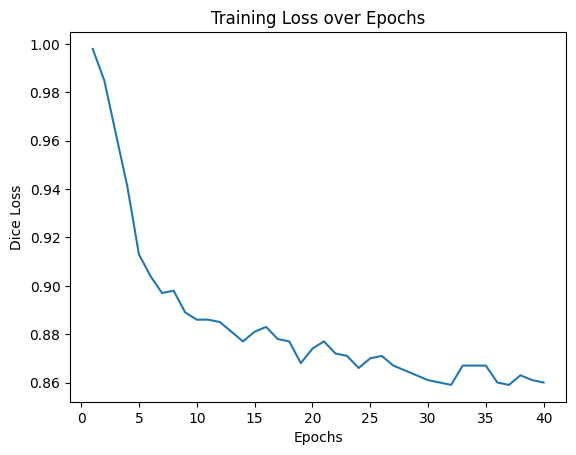

In [3]:
loss_val = [0.998,0.985,0.963,0.941,0.913,0.904,0.897,0.898,0.889,0.886,0.886,0.885,0.881,0.877,0.881,0.883,0.878,0.877,0.868,0.874,0.877,0.872,0.871,
            0.866,0.870,0.871,0.867,0.865,0.863,0.861,0.860,0.859,0.867,0.867,0.867,0.860,0.859,0.863,0.861,0.860]
import matplotlib.pyplot as plt
plt.plot(range(1, len(loss_val)+1), loss_val)
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.title('Training Loss over Epochs')
plt.show()

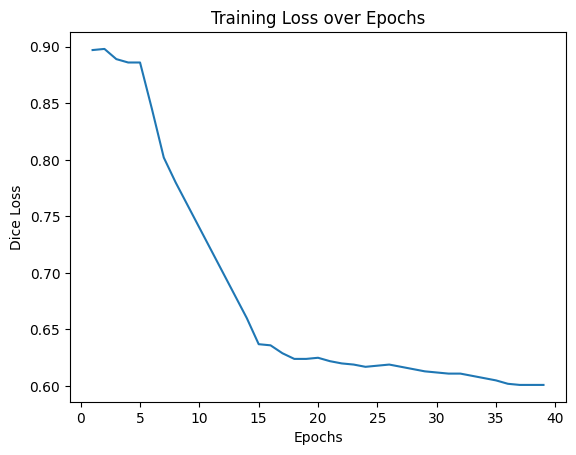

In [ ]:
loss_val = [0.897,0.898,0.889,0.886,0.886,0.845,0.802,0.780,0.760,0.740,0.720,0.700,0.680,0.660,0.637,0.636,
            0.629,0.624,0.624,0.625,0.622,0.620,0.619,0.617,0.618,0.619,0.617,0.615,0.613,0.612,0.611,0.611,0.609,0.607,0.605,0.602,0.601,0.601,0.601,
            0.602,0.601,0.600,0.599,0.598,0.597,0.596,0.595,0.594,0.593,0.592,0.591,0.590,0.589,0.588,0.587,0.586,0.585,0.584,0.583]
import matplotlib.pyplot as plt
plt.plot(range(1, len(loss_val)+1), loss_val)
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.title('Training Loss over Epochs')
plt.show()

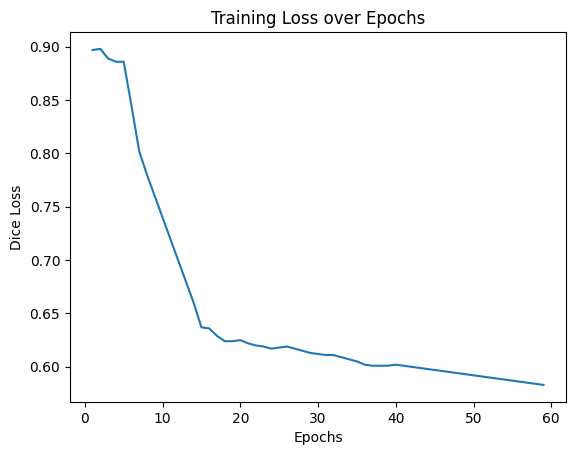

In [2]:
loss_val = [0.897,0.898,0.889,0.886,0.886,0.845,0.802,0.780,0.760,0.740,0.720,0.700,0.680,0.660,0.637,0.636,
            0.629,0.624,0.624,0.625,0.622,0.620,0.619,0.617,0.618,0.619,0.617,0.615,0.613,0.612,0.611,0.611,0.609,0.607,0.605,0.602,0.601,0.601,0.601,
            0.602,0.601,0.600,0.599,0.598,0.597,0.596,0.595,0.594,0.593,0.592,0.591,0.590,0.589,0.588,0.587,0.586,0.585,0.584,0.583]
import matplotlib.pyplot as plt
plt.plot(range(1, len(loss_val)+1), loss_val)
plt.xlabel('Epochs')
plt.ylabel('Dice Loss')
plt.title('Training Loss over Epochs')
plt.show()